In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

In [20]:
%pwd
df = pd.read_csv("sampleddata.csv")

In [21]:
df.describe()

,Unnamed: 0,id,epoch,replyCount,retweetCount,likeCount,quoteCount,week
count,25731.000000,2.573100e+04,2.573100e+04,25731.000000,25731.000000,25731.000000,25731.000000,25731.000000
mean,12865.000000,1.821739e+18,1.723171e+09,46.707163,125.625432,592.970192,7.220940,13.793246
std,7428.044224,2.196072e+16,5.235844e+06,781.186647,1554.005557,9461.016248,105.827581,8.657063
min,0.000000,1.785460e+18,1.714522e+09,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6432.500000,1.803812e+18,1.718897e+09,0.000000,0.000000,0.000000,0.000000,7.000000
50%,12865.000000,1.815038e+18,1.721574e+09,0.000000,0.000000,0.000000,0.000000,11.000000
75%,19297.500000,1.841152e+18,1.727800e+09,0.000000,0.000000,1.000000,0.000000,21.000000
max,25730.000000,1.863010e+18,1.733011e+09,54132.000000,84702.000000,670629.000000,5206.000000,30.000000


In [28]:
df.groupby('week')[['retweetCount','likeCount']].describe()

retweetCount                                                         \
            count         mean          std  min  25%  50%  75%      max   
week                                                                       
0           900.0    25.938889   371.367886  0.0  0.0  0.0  0.0  10424.0   
1          1000.0    43.879000   361.350711  0.0  0.0  0.0  0.0   3835.0   
2           540.0    33.240741   356.318307  0.0  0.0  0.0  0.0   7032.0   
3           740.0    70.682432   520.923735  0.0  0.0  0.0  0.0   8239.0   
4           719.0   109.166898   787.434224  0.0  0.0  0.0  0.0  11241.0   
5           818.0    67.023227   557.564140  0.0  0.0  0.0  0.0  12918.0   
6          1450.0    60.510345  1058.083336  0.0  0.0  0.0  0.0  37906.0   
7           940.0     7.887234   126.544482  0.0  0.0  0.0  0.0   2824.0   
8           645.0   149.275969  1064.686774  0.0  0.0  0.0  0.0  13040.0   
9          1235.0   139.323077  1650.968710  0.0  0.0  0.0  0.0  48517.0   
10         2385.0     1.734591    22.676702  0.0  0.0  0.0  0.0    904.0   
11         1980.0    36.071212   458.863519  0.0  0.0  0.0  0.0  11617.0   
12          420.0   389.347619  1997.031340  0.0  0.0  0.0  0.0  20627.0   
13           80.0     1.125000     5.027456  0.0  0.0  0.0  0.0     39.0   
14         1060.0     2.974528    40.077455  0.0  0.0  0.0  0.0   1082.0   
15         1140.0     5.454386   102.383931  0.0  0.0  0.0  0.0   3346.0   
16          200.0     1.645000    18.754135  0.0  0.0  0.0  0.0    264.0   
17          120.0     4.558333    45.900293  0.0  0.0  0.0  0.0    503.0   
18          184.0   628.907609  5647.543460  0.0  0.0  0.0  0.0  54217.0   
19          426.0    74.164319   693.690262  0.0  0.0  0.0  0.0   9830.0   
20         1169.0    74.256630  1184.072319  0.0  0.0  0.0  0.0  32064.0   
21         1326.0    29.468326   494.713331  0.0  0.0  0.0  0.0  14007.0   
22         1149.0   113.749347  1771.579319  0.0  0.0  0.0  0.0  41246.0   
23         1187.0   221.915754  1381.662374  0.0  0.0  0.0  0.0  14639.0   
24          338.0  1731.127219  5849.229413  0.0  0.0  0.0  0.0  36578.0   
25          460.0  1355.893478  6131.713423  0.0  0.0  0.0  0.0  84702.0   
26          360.0   986.630556  4464.674149  0.0  0.0  0.0  1.0  44991.0   
27          360.0   303.844444  1780.209569  0.0  0.0  0.0  0.0  20209.0   
28          840.0     1.083333    10.224895  0.0  0.0  0.0  0.0    204.0   
29         1020.0     2.551961    26.586837  0.0  0.0  0.0  0.0    605.0   
30          540.0     8.387037   109.616231  0.0  0.0  0.0  0.0   2157.0   

     likeCount                                                           
         count         mean           std  min  25%  50%  75%       max  
week                                                                     
0        900.0   124.153333   1645.083532  0.0  0.0  0.0  2.0   44345.0  
1       1000.0    37.600000    469.583945  0.0  0.0  0.0  2.0   13077.0  
2        540.0   162.016667   1536.748364  0.0  0.0  0.0  1.0   23783.0  
3        740.0   264.656757   1979.036138  0.0  0.0  0.0  1.0   25482.0  
4        719.0   431.378303   3479.973598  0.0  0.0  0.0  1.0   58116.0  
5        818.0   224.716381   2229.846986  0.0  0.0  0.0  1.0   47520.0  
6       1450.0    97.830345   1840.512539  0.0  0.0  0.0  1.0   65507.0  
7        940.0    15.603191    302.177463  0.0  0.0  0.0  1.0    9084.0  
8        645.0   118.376744   1249.819221  0.0  0.0  0.0  1.0   26580.0  
9       1235.0   111.878543   1666.428381  0.0  0.0  0.0  1.0   44972.0  
10      2385.0     8.295178    113.280437  0.0  0.0  0.0  1.0    5049.0  
11      1980.0   168.593939   2113.599136  0.0  0.0  0.0  1.0   47492.0  
12       420.0  1044.923810   6366.850508  0.0  0.0  0.0  1.0   84634.0  
13        80.0     3.812500     16.109667  0.0  0.0  0.0  1.0     130.0  
14      1060.0    15.659434    220.612929  0.0  0.0  0.0  1.0    6223.0  
15      1140.0    17.610526    223.570557  0.0  0.0  0.0  1.0    6501.0  
16       200.0

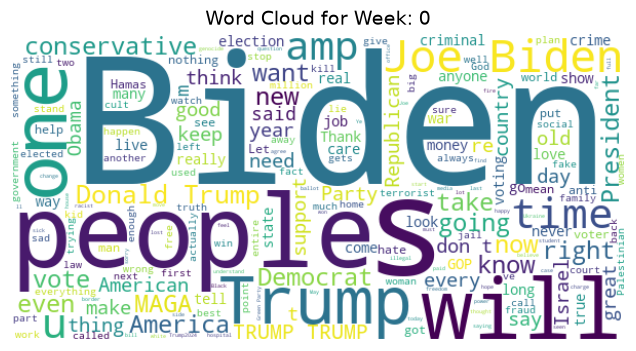

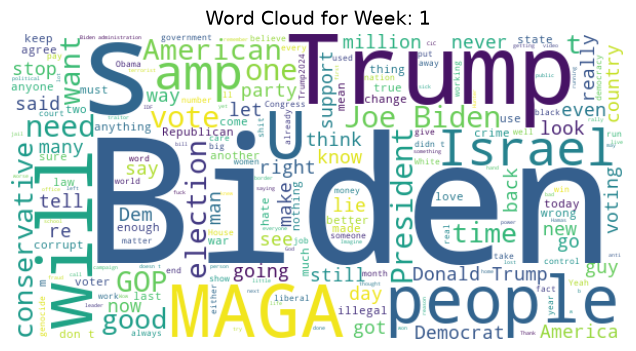

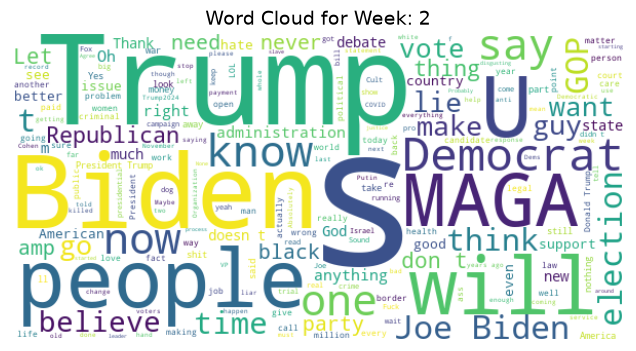

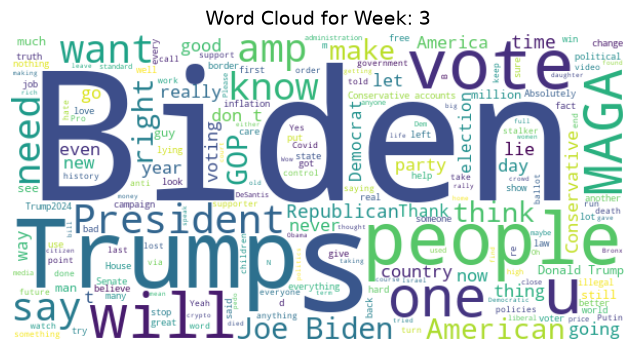

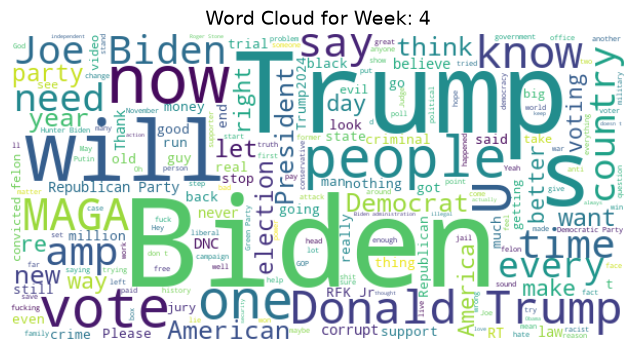

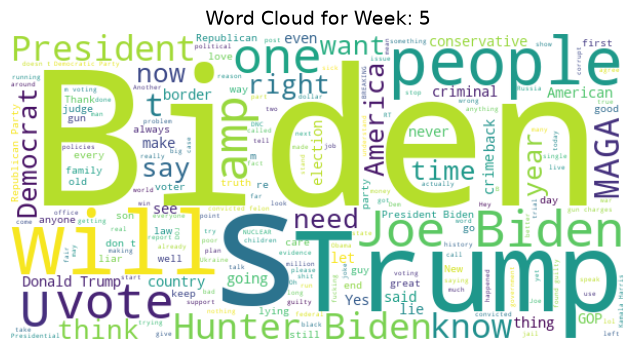

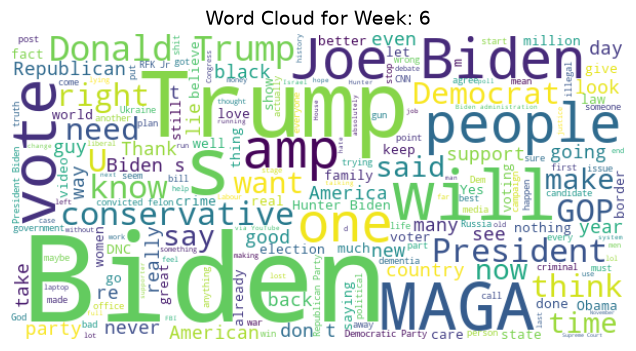

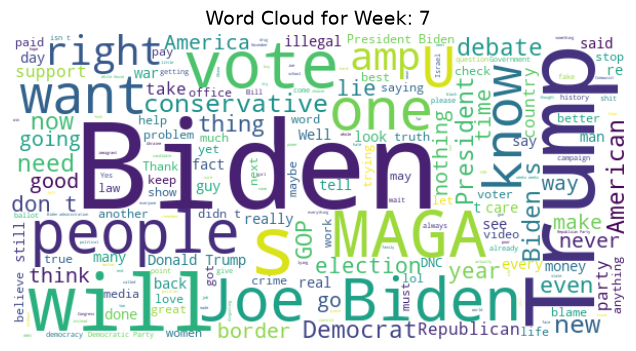

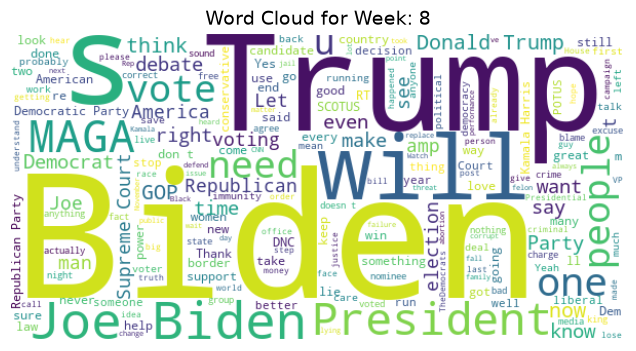

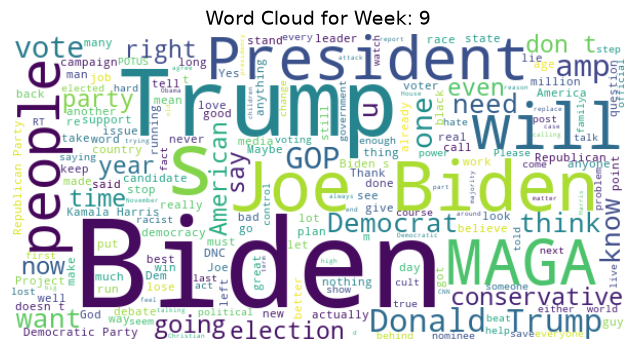

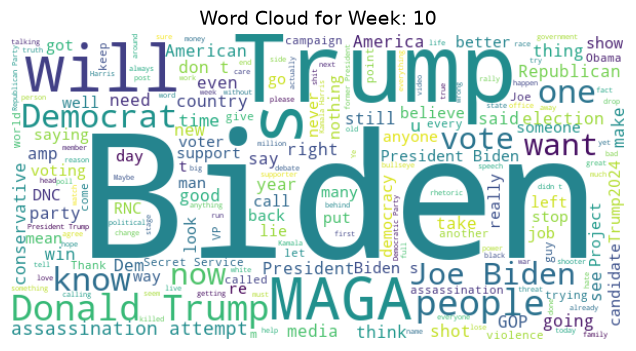

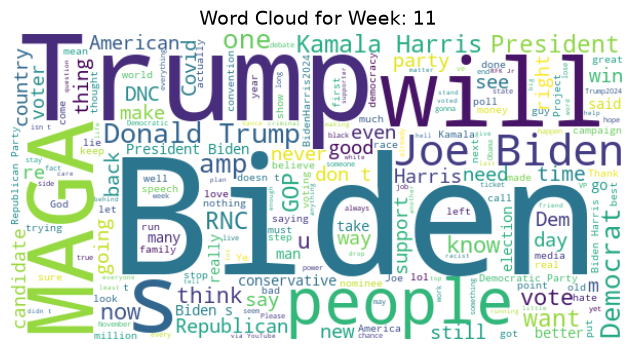

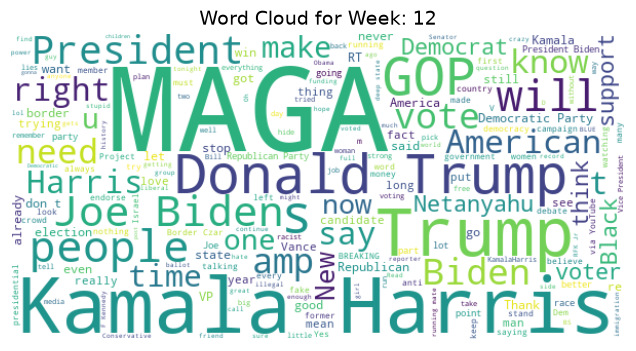

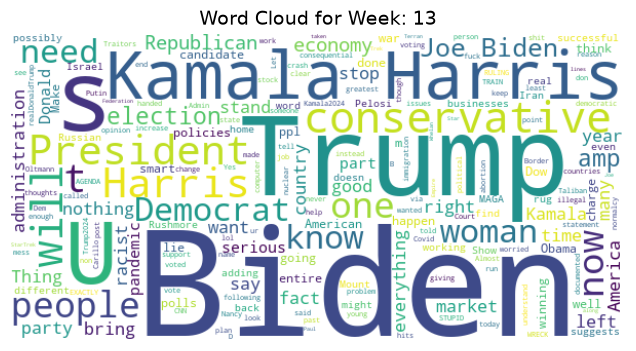

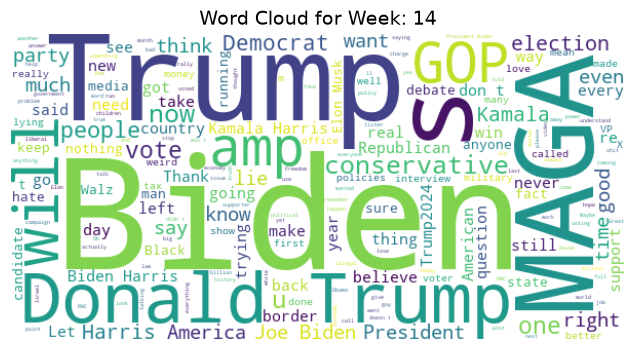

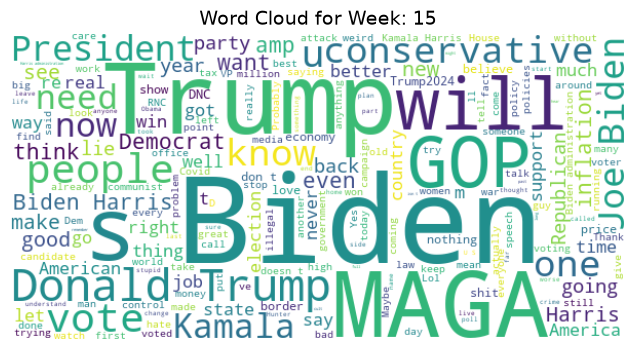

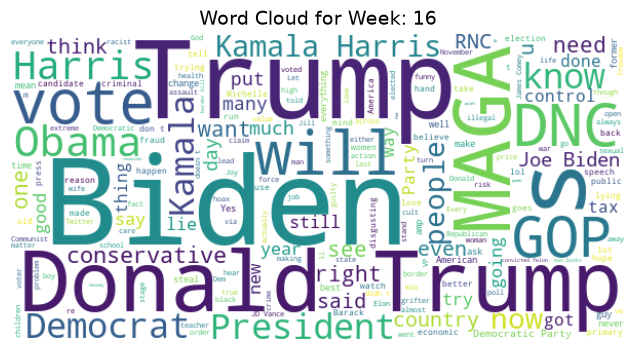

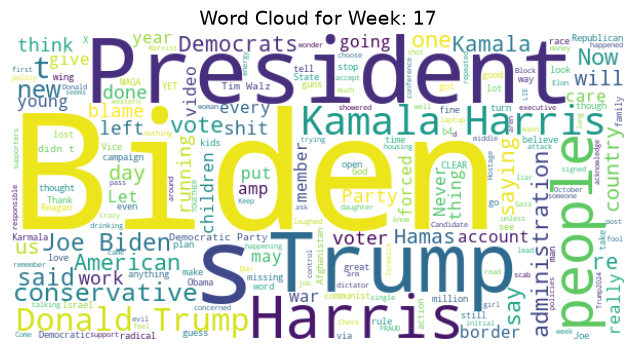

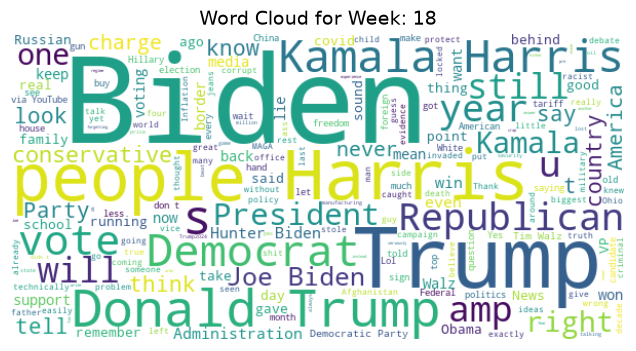

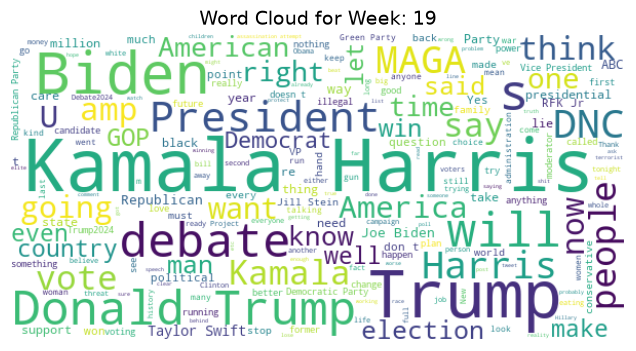

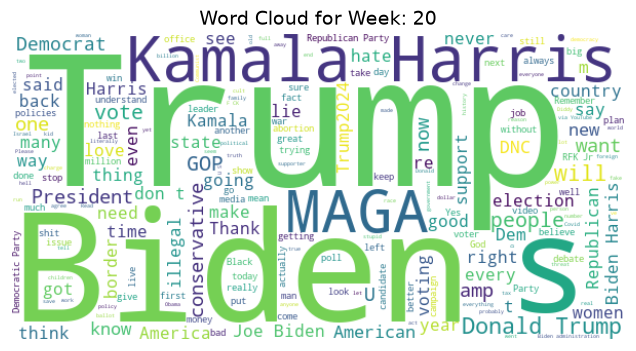

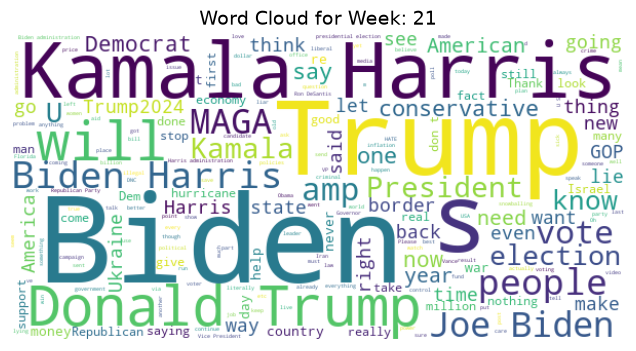

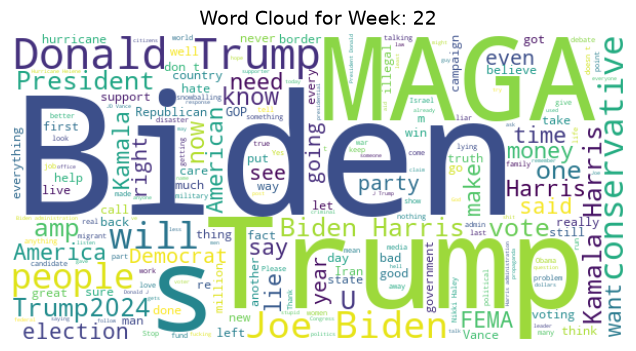

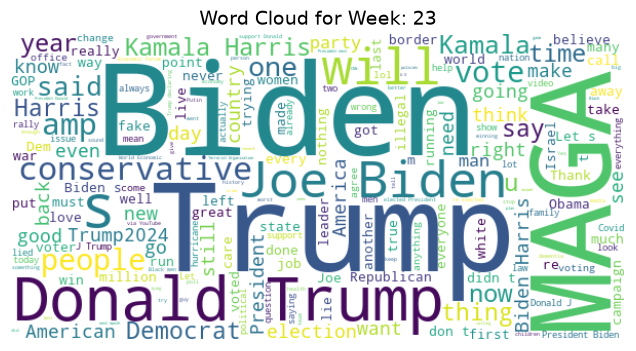

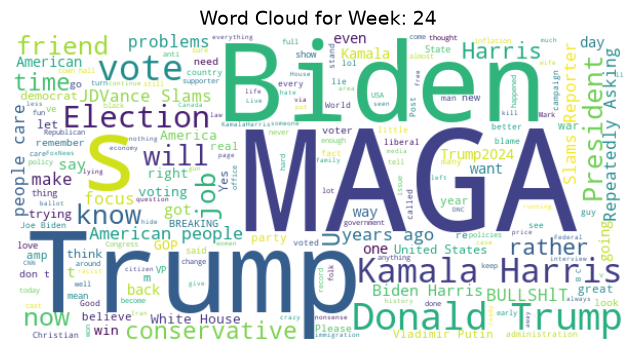

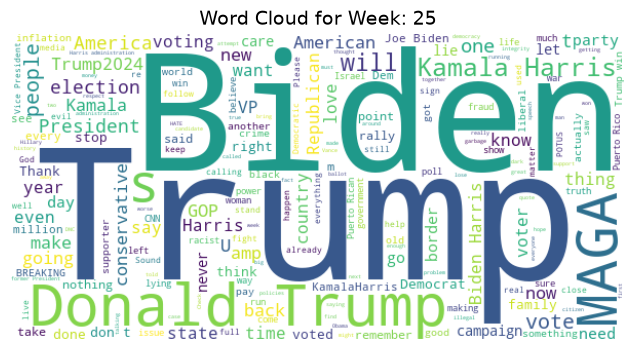

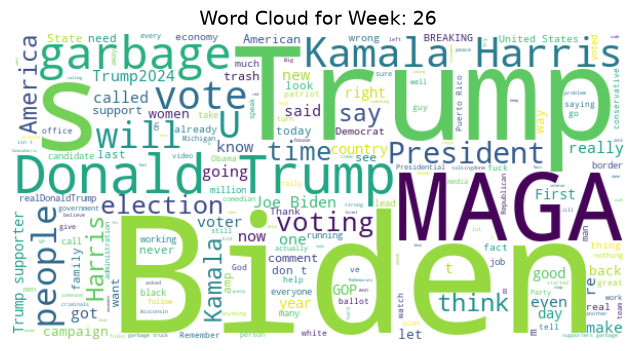

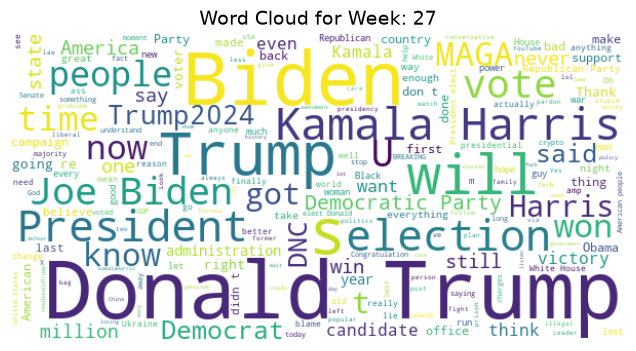

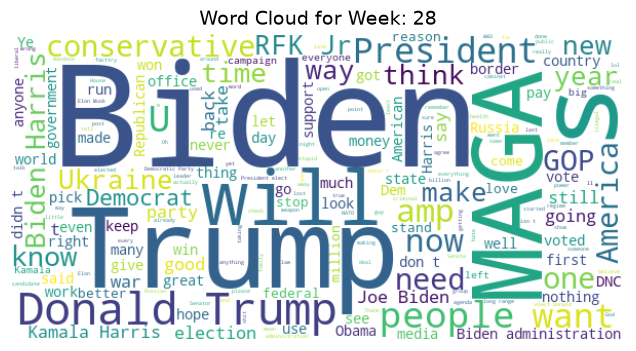

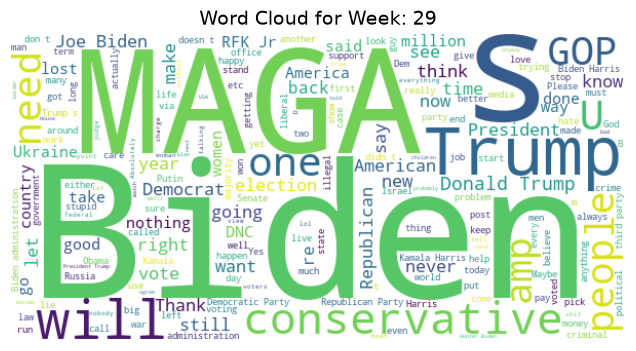

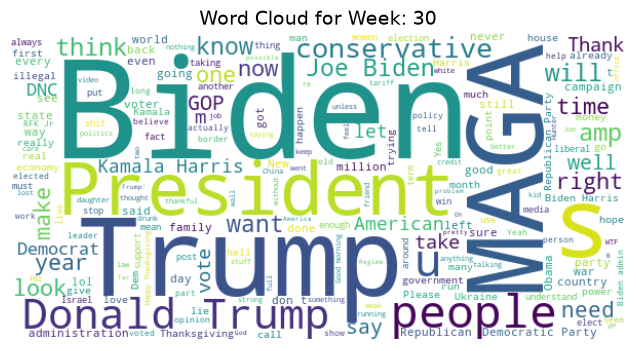

In [43]:
weekly_words = df.groupby('week')['cleanedTweet'].agg(' '.join)
stopwords = set(STOPWORDS)

for index, week in enumerate(weekly_words):
    # Generate the word cloud
    wordcloud = WordCloud(
        width=600,
        height=300,
        background_color='white',
        stopwords=set(STOPWORDS)
    ).generate(week)

    # Display the word cloud labeled by the week ending date
    plt.figure(figsize=(8, 4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Word Cloud for Week: {index}", fontsize=14)
    plt.axis('off')
    plt.show()